# `r_matrix` walkthrough: one tiny problem, step by step

This notebook runs the prototype **by hand** on a toy problem: 4 mock MPI tasks and about 50 observations. It prints the data structures after every stage. It calls the same functions that `r_matrix.run()` calls, in the same order, and at the end checks that `run()` gives the identical answer.

Read it next to `r_matrix/README.md`. It takes about 15 minutes.

**The one convention to remember:** every per-task quantity is a Python **list of length P**, and element `r` is what MPI task `r` would hold. A "communication" function takes the lists of *all* tasks at once and returns the lists of all tasks, just as if every task had called the MPI routine at the same moment.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

from r_matrix.decomposition import Domain, Decomposition
from r_matrix.comm import MockComm
from r_matrix.generate import make_obs
from r_matrix.redistribute import redistribute, check_redistribution
from r_matrix.halo import discover_halos
from r_matrix.commmap import build_comm_maps, halo_exchange
from r_matrix.covariance import LocalSolver, build_R
from r_matrix.reference import global_solve

COLORS = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100"]   # one per task
MARKERS = ["o", "s", "^", "D"]                             # second encoding, so colour is not the only cue
INK2 = "#52514e"
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
pd.set_option("display.float_format", "{:.3f}".format)

def draw_cells(ax, dec):
    for r in range(dec.size):
        x0, x1, y0, y1 = dec.cell_rect(r)
        ax.add_patch(Rectangle((x0, y0), x1 - x0, y1 - y0, fill=False, ec=INK2, lw=0.8))
        ax.text(x0 + 0.05, y1 - 0.05, f"task {r}", va="top", fontsize=8, color=INK2)
    d = dec.domain
    ax.set_xlim(d.xmin, d.xmax); ax.set_ylim(d.ymin, d.ymax); ax.set_aspect("equal")

def by_task(ax, arrays, label="task"):
    for r, a in enumerate(arrays):
        ax.scatter(a["x"], a["y"], s=30, c=COLORS[r], marker=MARKERS[r], ec="white", lw=0.5,
                   label=f"{label} {r} ({len(a)})")

## 0. Problem set-up

| Symbol | Code | Value | Meaning |
|---|---|---|---|
| domain | `Domain(0, 3, 0, 3)` | 3 × 3 | the physical region |
| $P_x \times P_y$ | `Decomposition(dom, 2, 2)` | 2 × 2 = 4 tasks | each subdomain (core cell) is 1.5 × 1.5 |
| $\ell$ | `c` | 0.5 | Gaspari–Cohn length scale; correlations vanish beyond $2\ell$ = 1.0 |
| $\alpha$ | `alpha` | 0.8 | correlated fraction of the error variance (nugget 0.2) |
| $h$ | `h` | 0.75 = 1.5 $\ell$ | halo width, **in domain units** |

In [2]:
dom = Domain(0.0, 3.0, 0.0, 3.0)
dec = Decomposition(dom, px=2, py=2)
P = dec.size
C, ALPHA, H = 0.5, 0.8, 0.75
comm = MockComm(P)          # the "communicator": it just counts traffic
print(f"P = {P} tasks, cell = {dec.dx} x {dec.dy}, h/l = {H / C}")

P = 4 tasks, cell = 1.5 x 1.5, h/l = 1.5


## 1. Observations start on random tasks
`make_obs` returns a list: `obs_init[r]` is the structured numpy array of the records on task `r`.
The locations have nothing to do with the task number (compare deck slide 2).

In [3]:
obs_init = make_obs(50, dom, P, seed=3, departures="correlated", c=C, alpha=ALPHA)
print("records per task:", [len(o) for o in obs_init])
pd.DataFrame(obs_init[0])       # task 0's records; note orig_rank / orig_index = where the record lives now

records per task: [11, 13, 17, 9]


,global_id,x,y,value,sigma,orig_rank,orig_index
0,1014,1.890,2.124,2.080,0.956,0,0
1,1077,0.894,0.641,-0.029,1.083,0,1
2,1287,2.048,1.769,0.466,0.933,0,2
3,1175,2.460,2.009,0.664,0.879,0,3
4,1021,2.635,1.664,-0.361,0.859,0,4
5,1245,1.182,0.376,-0.944,0.890,0,5
6,1259,1.839,1.166,-0.886,1.015,0,6
7,1112,2.576,1.715,-1.405,1.114,0,7
8,1252,0.890,1.856,0.069,0.864,0,8
9,1049,1.479,1.747,-0.770,0.977,0,9


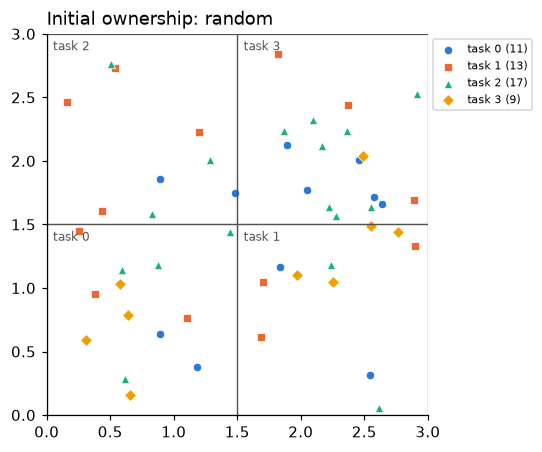

In [4]:
fig, ax = plt.subplots(figsize=(4.5, 4.5))
by_task(ax, obs_init); draw_cells(ax, dec)
ax.set_title("Initial ownership: random", loc="left"); ax.legend(fontsize=7, loc="upper left", bbox_to_anchor=(1, 1));

## 2. Spatial ownership and redistribution
`dec.owner(x, y)` gives the spatial owner, $i + P_x j$. Each task computes it for its own records.

In [5]:
o = obs_init[0]
pd.DataFrame({"global_id": o["global_id"], "x": o["x"], "y": o["y"], "spatial owner": dec.owner(o["x"], o["y"])}).head(8)

,global_id,x,y,spatial owner
0,1014,1.890,2.124,3
1,1077,0.894,0.641,0
2,1287,2.048,1.769,3
3,1175,2.460,2.009,3
4,1021,2.635,1.664,3
5,1245,1.182,0.376,0
6,1259,1.839,1.166,1
7,1112,2.576,1.715,3


`redistribute` does steps A–E of deck slide 4 for all tasks. It returns:
* `owned[r]`: the records now on task `r`, **sorted by `global_id`**. The position in this array is the `owned_local_index`.
* `rejected[r]`: the records task `r` screened out (NaN or outside the domain). None here.
* `plan`: the frozen routing, reused later to move bare values instead of whole records.

`plan.sendcounts` is the $P \times P$ matrix "how many records task *row* sends to task *column*". It is what goes into `MPI_Alltoall`.

In [6]:
owned, rejected, plan = redistribute(comm, dec, obs_init)
check_redistribution(obs_init, owned, rejected, dec)      # raises if anything was lost or misplaced
pd.DataFrame(np.array(plan.sendcounts), index=[f"from {r}" for r in range(P)], columns=[f"to {r}" for r in range(P)])

,to 0,to 1,to 2,to 3
from 0,2,2,2,5
from 1,3,3,4,3
from 2,4,2,3,8
from 3,4,4,0,1


In [7]:
pd.DataFrame(owned[0])   # all inside task 0's cell, sorted by global_id; orig_rank shows where each came from

,global_id,x,y,value,sigma,orig_rank,orig_index
0,1077,0.894,0.641,-0.029,1.083,0,1
1,1098,0.380,0.954,0.682,1.007,1,11
2,1126,1.439,1.442,0.102,1.015,2,4
3,1147,0.590,1.141,1.240,1.152,2,9
4,1154,0.876,1.181,0.708,0.966,2,6
5,1182,0.255,1.446,-0.307,0.949,1,10
6,1217,0.617,0.280,-0.197,1.015,2,11
7,1224,0.656,0.156,0.729,1.005,3,0
8,1231,1.108,0.761,-0.170,0.923,1,9
9,1238,0.581,1.028,1.567,1.106,3,7


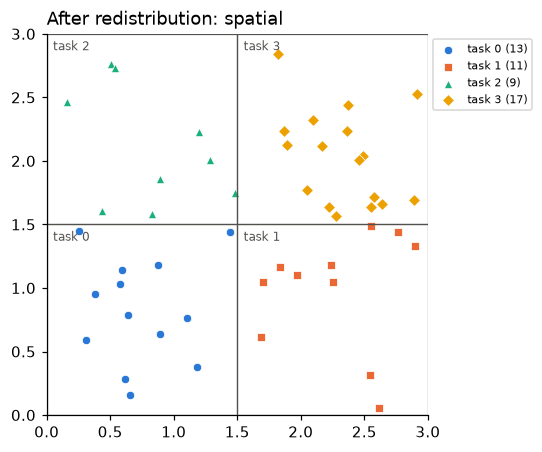

In [8]:
fig, ax = plt.subplots(figsize=(4.5, 4.5))
by_task(ax, owned); draw_cells(ax, dec)
ax.set_title("After redistribution: spatial", loc="left"); ax.legend(fontsize=7, loc="upper left", bbox_to_anchor=(1, 1));

**Recurring moves use the plan.** Inside a minimisation, the vector changes every iteration, but the locations do not.
`plan.forward` moves plain float64 values to the spatial owners, and `plan.reverse` moves them back. Here we check the round trip:

In [9]:
values = [o["value"] for o in obs_init]              # a vector living on the original tasks
on_owners = plan.forward(comm, values)
print("forward gives the owned order:", all(np.array_equal(v, o["value"]) for v, o in zip(on_owners, owned)))
back = plan.reverse(comm, on_owners)
print("reverse restores the original:", all(np.array_equal(v, b) for v, b in zip(values, back)))

forward gives the owned order: True
reverse restores the original: True


## 3. Halo discovery
Each owner pushes a record to every other task whose cell, expanded by $h$, contains it. The receiver keeps the records within distance $h$ of its cell (the "rect" criterion).
`halos[r]` is sorted by (owner, `global_id`), so the halo from each owner forms one contiguous block. `halo_owner[r]` says which task owns each halo record.

In [10]:
halos, halo_owner, hstats = discover_halos(comm, dec, owned, H)
for r, s in enumerate(hstats):
    print(f"task {r}: core {s.core:2d}, candidates received {s.candidates:2d}, halo kept {s.halo:2d}")
df = pd.DataFrame(halos[0])[["global_id", "x", "y", "value"]]
df.insert(0, "owner", halo_owner[0])
df

task 0: core 13, candidates received 16, halo kept 14
task 1: core 11, candidates received 23, halo kept 22
task 2: core  9, candidates received 19, halo kept 18
task 3: core 17, candidates received 16, halo kept 15


,owner,global_id,x,y,value
0,1,1000,1.701,1.044,0.349
1,1,1007,1.685,0.616,0.107
2,1,1168,2.241,1.179,0.825
3,1,1210,1.973,1.105,0.373
4,1,1259,1.839,1.166,-0.886
5,2,1049,1.479,1.747,-0.770
6,2,1091,1.199,2.224,-0.478
7,2,1252,0.890,1.856,0.069
8,2,1273,1.286,2.007,-0.611
9,2,1301,0.439,1.609,1.211


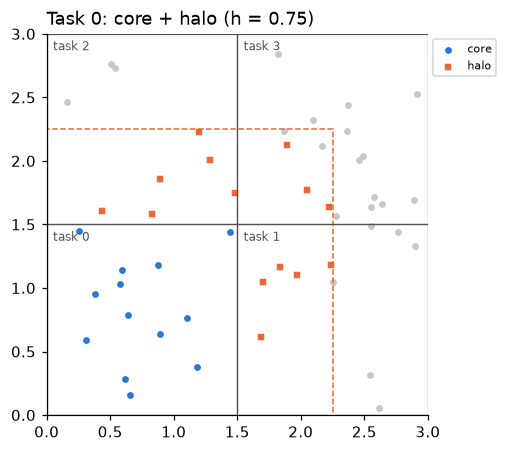

In [11]:
r0 = 0
x0, x1, y0, y1 = dec.cell_rect(r0)
fig, ax = plt.subplots(figsize=(4.5, 4.5))
allobs = np.concatenate(owned)
ax.scatter(allobs["x"], allobs["y"], s=12, c="#c9c8c2")
ax.scatter(owned[r0]["x"], owned[r0]["y"], s=30, c=COLORS[0], marker="o", ec="white", label="core")
ax.scatter(halos[r0]["x"], halos[r0]["y"], s=30, c=COLORS[1], marker="s", ec="white", label="halo")
ax.add_patch(Rectangle((x0 - H, y0 - H), x1 - x0 + 2*H, y1 - y0 + 2*H, fill=False, ec=COLORS[1], ls="--"))
draw_cells(ax, dec)
ax.set_title(f"Task {r0}: core + halo (h = {H})", loc="left"); ax.legend(fontsize=7, loc="upper left", bbox_to_anchor=(1, 1));

## 4. The frozen communication map
`build_comm_maps` runs the handshake of deck slide 7 once. It returns one `RankMap` per task:
* `recv[owner]`: the slice of `halos[r]` that comes from `owner`;
* `send[dest]`: the indices into `owned[r]` to send to `dest`, in exactly the order `dest` expects.

In [12]:
maps = build_comm_maps(comm, owned, halos, halo_owner)
for m in maps:
    print(f"task {m.rank}: recv {m.recv}")
    print(f"        send { {d: idx.tolist() for d, idx in m.send.items()} }")

task 0: recv {1: slice(0, 5, None), 2: slice(5, 11, None), 3: slice(11, 14, None)}
        send {1: [0, 2, 4, 8, 10], 2: [1, 2, 3, 4, 5, 8, 9, 12], 3: [2, 4]}
task 1: recv {0: slice(0, 5, None), 2: slice(5, 9, None), 3: slice(9, 22, None)}
        send {0: [0, 1, 6, 7, 8], 2: [0, 7, 8], 3: [0, 4, 5, 6, 7, 8, 9, 10]}
task 2: recv {0: slice(0, 8, None), 1: slice(8, 11, None), 3: slice(11, 18, None)}
        send {0: [1, 3, 5, 6, 7, 8], 1: [1, 5, 6, 8], 3: [1, 3, 5, 6, 8]}
task 3: recv {0: slice(0, 2, None), 1: slice(2, 10, None), 2: slice(10, 15, None)}
        send {0: [0, 6, 12], 1: [0, 1, 2, 3, 5, 6, 7, 8, 10, 12, 13, 14, 15], 2: [0, 6, 9, 10, 12, 14, 16]}


In [13]:
# A recurring halo update: only values travel, and only between real neighbours.
d_core = [o["value"] for o in owned]
d_halo = halo_exchange(comm, maps, d_core)
print("halo values equal the owners' values:", all(np.array_equal(dh, hh["value"]) for dh, hh in zip(d_halo, halos)))

halo values equal the owners' values: True


## 5. Why a halo is needed at all: $R$ is sparse, $R^{-1}$ is not
The global $R$ for all 50 observations, ordered task by task, shown as $\log_{10}|\cdot|$.
$R$ has exact zeros beyond $2\ell$. $R^{-1}$ is dense: every observation influences every other, with a weight that decays with distance.
Truncating $R^{-1}$ at the halo edge is the approximation, and its error is what the prototype measures.

fraction of exact zeros: R 68%,  R^-1 0%


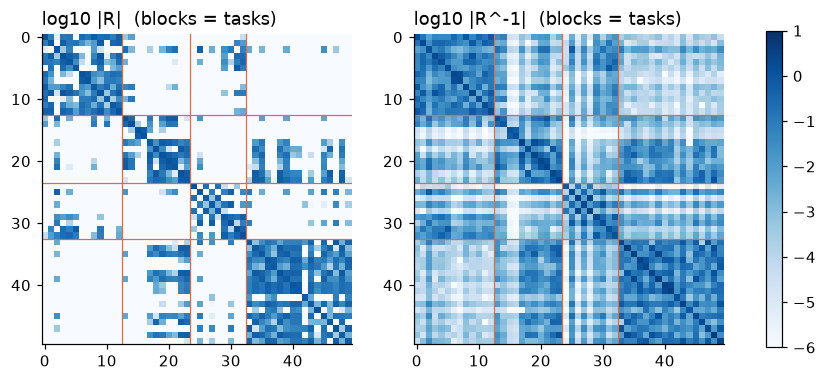

In [14]:
ordered = np.concatenate(owned)                       # task 0 obs, then task 1, ...
R = build_R(ordered["x"], ordered["y"], ordered["sigma"], C, ALPHA)
Rinv = np.linalg.inv(R)
edges = np.cumsum([len(o) for o in owned])[:-1] - 0.5
fig, axs = plt.subplots(1, 2, figsize=(10, 4.4))
for ax, M, t in zip(axs, (R, Rinv), ("log10 |R|", "log10 |R^-1|")):
    im = ax.imshow(np.log10(np.abs(M) + 1e-12), vmin=-6, vmax=1, cmap="Blues")
    for e in edges:
        ax.axhline(e, color=COLORS[1], lw=0.8); ax.axvline(e, color=COLORS[1], lw=0.8)
    ax.set_title(t + "  (blocks = tasks)", loc="left")
fig.colorbar(im, ax=axs, shrink=0.85)
print(f"fraction of exact zeros: R {np.mean(R == 0):.0%},  R^-1 {np.mean(np.abs(Rinv) < 1e-14):.0%}")

## 6. Local solves
Each task builds $R_{loc}$ over [core, halo] and factorises it once (`LocalSolver`). Then `apply` solves $R_{loc} z = [d_{core}; d_{halo}]$ and **keeps only the core part**.

In [15]:
solvers = [LocalSolver(o, hh, C, ALPHA) for o, hh in zip(owned, halos)]
for r, s in enumerate(solvers):
    print(f"task {r}: local system {s.n} x {s.n} = {s.ncore} core + {s.nhalo} halo")
z_core = [s.apply(dc, dh) for s, dc, dh in zip(solvers, d_core, d_halo)]
z_orig = plan.reverse(comm, z_core)                    # results go back to the original tasks

task 0: local system 27 x 27 = 13 core + 14 halo
task 1: local system 33 x 33 = 11 core + 22 halo
task 2: local system 27 x 27 = 9 core + 18 halo
task 3: local system 32 x 32 = 17 core + 15 halo


Compare with the exact global answer, which is what you would get with no decomposition:

In [16]:
gids, z_exact, _, _ = global_solve(owned, C, ALPHA)
rows = []
for r, o in enumerate(obs_init):
    ex = z_exact[np.searchsorted(gids, o["global_id"])]
    for i in range(len(o)):
        rows.append({"orig task": r, "global_id": o["global_id"][i], "spatial owner": dec.owner(o["x"][i], o["y"][i]),
                     "z~ (core+halo)": z_orig[r][i], "z* (exact)": ex[i], "error": z_orig[r][i] - ex[i]})
cmp = pd.DataFrame(rows)
z_all, zx_all = cmp["z~ (core+halo)"].to_numpy(), cmp["z* (exact)"].to_numpy()
print(f"relative L2 error = {np.linalg.norm(z_all - zx_all) / np.linalg.norm(zx_all):.2e}")
cmp.head(10)

relative L2 error = 1.13e-02


,orig task,global_id,spatial owner,z~ (core+halo),z* (exact),error
0,0,1014,3,2.249,2.250,-0.001
1,0,1077,0,-0.458,-0.457,-0.001
2,0,1287,3,-0.048,-0.046,-0.002
3,0,1175,3,3.981,3.980,0.000
4,0,1021,3,1.108,1.108,-0.000
5,0,1245,0,-1.139,-1.138,-0.001
6,0,1259,1,-3.061,-3.072,0.011
7,0,1112,3,-3.317,-3.317,-0.000
8,0,1252,2,-0.194,-0.238,0.045
9,0,1049,2,-1.439,-1.377,-0.062


## 7. What did it cost?
`comm.stats` counts off-task bytes and messages per phase. `setup:*` happens once. `recurring:*` would happen at every application of $R^{-1}$.
The round-trip check in section 2 also used the default phase names, so `recurring:reverse` shows 2 calls: that check, and the real return in section 6.

In [17]:
pd.DataFrame(comm.stats.table()).T

,calls,bytes,messages,max_peers
setup:redistribute:counts,1,96,12,3
setup:redistribute:records,1,1968,11,3
recurring:forward,1,328,11,3
recurring:reverse,2,656,22,3
setup:halo:counts,1,96,12,3
setup:halo:records,1,3552,12,3
setup:map:counts,1,96,12,3
setup:map:requests,1,552,12,3
setup:map:confirm_counts,1,96,12,3
setup:map:confirm,1,192,12,3


## 8. `run()` does all of the above in one call

In [18]:
from r_matrix import Config, run
res = run(Config(n_obs=50, domain=dom, px=2, py=2, seed=3, c=C, alpha=ALPHA, h=H))
print(f"run(): relative L2 error = {res.metrics['rel_l2']:.2e}")
print("identical to the manual result:", all(np.allclose(a, b, rtol=0, atol=0) for a, b in zip(res.z_orig, z_orig)))

run(): relative L2 error = 1.13e-02
identical to the manual result: True


## Where next
* `02_experiments.ipynb`: the full experiments (3000 obs, sweeps over $h/\ell$, α, density, decompositions and patterns).
* `r_matrix/README.md`, sections "Extending the code" and "Starter exercises".
* Try it: change `H` to 0.5, 1.0 and 3.0 above and re-run. What happens to the halo sizes and the error? Why does `H = 3.0` give an error of about 1e-15?